# Numerical demonstration of Uhlmann’s theorem

**Author:** Wayne Dam\
**Date:** July 2026

**Libraries:** NumPy, Matplotlib

**Textbook Sections:**\
**Wilde §5.1** or **KLW §3.2.5** for purification.\
**Watrous §1.1.3** or **KLW §§2.2.7–2.2.9** for trace norm and polar decomposition.\
**KLW §6.2**, through Theorem 6.8, or **Wilde §9.2**, through Theorem 9.2.1, for the squared-fidelity version of Uhlmann’s
theorem.\
**Watrous §3.2.2** for a more abstract and mathematically systematic treatment.\

Will continue in following weeks with KLW Theorem 6.9, Theorem 6.14, and Lemma 6.15 for channel monotonicity, Fuchs–van
 de Graaf, and gentle
measurement.

**Generated with AI Assistance**
This Jupyter notebook was developed with the assistance of [ChatGPT](https://chatgpt.com/) (OpenAI).
- **Usage:** The AI was used to write initial boilerplate code and debug errors.
- *Note: Generated code, logic, and outputs have been reviewed, verified, and modified by the author.*



## Symmetric random unitary rotations of both purifying systems

This notebook numerically illustrates Uhlmann’s theorem for two finite-dimensional density operators
$\rho_A$ and $\sigma_A$.

We use the **squared fidelity convention**

$$
F(\rho,\sigma)
=
\left\|
\sqrt{\rho}\sqrt{\sigma}
\right\|_1^2.
$$

The theorem states that

$$
F(\rho,\sigma)
=
\max_{\substack{|\Psi_\rho\rangle,\;|\Psi_\sigma\rangle\\
\operatorname{Tr}_R |\Psi_\rho\rangle\langle\Psi_\rho|=\rho\\
\operatorname{Tr}_R |\Psi_\sigma\rangle\langle\Psi_\sigma|=\sigma}}
\left|
\langle\Psi_\rho|\Psi_\sigma\rangle
\right|^2.
$$

The notebook does **not** construct purifications from the vector
$\sum_i |i\rangle_R|i\rangle_A$.
Instead, it constructs each purification directly from the spectral decomposition of its density matrix.

The experiment then independently rotates the two reference systems:

$$
|\Psi_\rho(U_\rho)\rangle
=
(U_\rho\otimes I_A)|\Psi_\rho\rangle,
$$

$$
|\Psi_\sigma(U_\sigma)\rangle
=
(U_\sigma\otimes I_A)|\Psi_\sigma\rangle.
$$

For every random pair $(U_\rho,U_\sigma)$, we compute

$$
\left|
\langle\Psi_\rho(U_\rho)
|
\Psi_\sigma(U_\sigma)\rangle
\right|^2,
$$

and track the largest sampled value. The running maximum should approach
$F(\rho,\sigma)$ from below as more random unitary pairs are tried.

## 1. Direct spectral purifications

Let

$$
\rho_A
=
\sum_{i=1}^{d} p_i |e_i\rangle\langle e_i|,
\qquad
\sigma_A
=
\sum_{j=1}^{d} q_j |f_j\rangle\langle f_j|.
$$

Choose a fixed orthonormal basis

$$
\{|1\rangle_R,\ldots,|d\rangle_R\}
$$

for the reference system $R$. We form the standard spectral purifications

$$
|\Psi_\rho\rangle_{RA}
=
\sum_{i=1}^{d}
\sqrt{p_i}\,
|i\rangle_R |e_i\rangle_A,
$$

$$
|\Psi_\sigma\rangle_{RA}
=
\sum_{j=1}^{d}
\sqrt{q_j}\,
|j\rangle_R |f_j\rangle_A.
$$

Tracing out $R$ recovers the original density matrices:

$$
\operatorname{Tr}_R
\left(
|\Psi_\rho\rangle\langle\Psi_\rho|
\right)
=
\rho,
$$

$$
\operatorname{Tr}_R
\left(
|\Psi_\sigma\rangle\langle\Psi_\sigma|
\right)
=
\sigma.
$$

This is the purification construction reviewed before the proof of Uhlmann’s theorem.

## 2. Why we rotate both reference systems

To treat the two purifications symmetrically, we independently draw two Haar-random unitaries

$$
U_\rho,\;U_\sigma\in U(d)
$$

and rotate both reference systems.

The resulting overlap is

$$
\begin{aligned}
\langle\Psi_\rho(U_\rho)|\Psi_\sigma(U_\sigma)\rangle
&=
\langle\Psi_\rho|
(U_\rho^\dagger U_\sigma\otimes I_A)
|\Psi_\sigma\rangle.
\end{aligned}
$$

Therefore only the **relative unitary**

$$
V=U_\rho^\dagger U_\sigma
$$

affects the overlap.

Because $U_\rho$ and $U_\sigma$ are independent Haar-random unitaries, the relative unitary
$V$ is itself Haar distributed. Thus rotating both sides is mathematically equivalent to optimizing
over one relative unitary, but it removes any artificial asymmetry from the numerical procedure.

## 3. Numerical plan

The notebook performs the following steps.

1. Generate two random density matrices $\rho$ and $\sigma$.
2. Diagonalize each density matrix.
3. Construct its spectral purification in a fixed basis of $R$.
4. Verify numerically that tracing out $R$ recovers the original state.
5. Compute the exact squared fidelity

   $$
   F(\rho,\sigma)
   =
   \left\|
   \sqrt{\rho}\sqrt{\sigma}
   \right\|_1^2.
   $$

6. Draw many independent pairs $(U_\rho,U_\sigma)$ from the Haar measure.
7. Rotate both reference systems and compute the squared purification overlap.
8. Track the running maximum

   $$
   M_N
   =
   \max_{1\leq k\leq N}
   \left|
   \langle\Psi_\rho(U_{\rho,k})
   |
   \Psi_\sigma(U_{\sigma,k})\rangle
   \right|^2.
   $$

9. Compare $M_N$ with the exact fidelity.

For every finite sample,

$$
M_N\leq F(\rho,\sigma)
$$

up to floating-point roundoff. As $N$ grows, $M_N$ should move upward toward the exact value.

In [30]:
# Core numerical libraries.
import numpy as np
import matplotlib.pyplot as plt

# Make printed arrays easier to read.
np.set_printoptions(precision=5, suppress=True)

# ------------------------------------------------------------
# User-adjustable experiment parameters
# ------------------------------------------------------------

# Hilbert-space dimension of both A and R.
# d = 2 gives a qubit example and converges quickly.
# d = 3 gives a qutrit example but random search converges more slowly.
d = 2

# Number of independently sampled pairs (U_rho, U_sigma).
# Increasing this generally improves the best sampled overlap,
# but the improvement is stochastic rather than deterministic.
number_of_trials = 50_000

# Reproducible random-number generator.
random_seed = 20260709
rng = np.random.default_rng(random_seed)

print(f"Dimension d = {d}")
print(f"Number of random unitary pairs = {number_of_trials:,}")
print(f"Random seed = {random_seed}")

Dimension d = 2
Number of random unitary pairs = 50,000
Random seed = 20260709


## 4. Generate two density matrices

A convenient way to generate a full-rank random density matrix is to draw a complex matrix $G$
and form

$$
\rho
=
\frac{GG^\dagger}{\operatorname{Tr}(GG^\dagger)}.
$$

This automatically gives

$$
\rho\geq 0,
\qquad
\operatorname{Tr}(\rho)=1.
$$

We generate $\rho$ and $\sigma$ independently in this way.

In [31]:
# Draw a complex Ginibre matrix for rho.
# Each entry has independent real and imaginary Gaussian parts.
G_rho = (
    rng.normal(size=(d, d))
    + 1j * rng.normal(size=(d, d))
) / np.sqrt(2.0)

# Convert the random matrix into a positive semidefinite matrix,
# then normalize it to have trace one.
rho = G_rho @ G_rho.conj().T
rho = rho / np.trace(rho)

# Repeat the same construction independently for sigma.
G_sigma = (
    rng.normal(size=(d, d))
    + 1j * rng.normal(size=(d, d))
) / np.sqrt(2.0)

sigma = G_sigma @ G_sigma.conj().T
sigma = sigma / np.trace(sigma)

print("rho =")
print(rho)
print("\nsigma =")
print(sigma)

# Basic sanity checks.
print("\nSanity checks")
print("Tr(rho)   =", np.trace(rho))
print("Tr(sigma) =", np.trace(sigma))
print("rho Hermitian?   ", np.allclose(rho, rho.conj().T))
print("sigma Hermitian? ", np.allclose(sigma, sigma.conj().T))
print("Eigenvalues of rho:  ", np.linalg.eigvalsh(rho))
print("Eigenvalues of sigma:", np.linalg.eigvalsh(sigma))

rho =
[[ 0.47138+0.j      -0.43134-0.10717j]
 [-0.43134+0.10717j  0.52862-0.j     ]]

sigma =
[[0.5417 +0.j      0.10495+0.39155j]
 [0.10495-0.39155j 0.4583 -0.j     ]]

Sanity checks
Tr(rho)   = (1+1.5407439555097887e-33j)
Tr(sigma) = (1+5.7777898331617076e-34j)
rho Hermitian?    True
sigma Hermitian?  True
Eigenvalues of rho:   [0.05463 0.94537]
Eigenvalues of sigma: [0.09249 0.90751]


## 5. Diagonalize the states and construct their purifications

Numerical diagonalization gives

$$
\rho
=
\sum_i p_i |e_i\rangle\langle e_i|,
\qquad
\sigma
=
\sum_j q_j |f_j\rangle\langle f_j|.
$$

We then directly build

$$
|\Psi_\rho\rangle
=
\sum_i \sqrt{p_i}\,|i\rangle_R|e_i\rangle_A,
$$

$$
|\Psi_\sigma\rangle
=
\sum_j \sqrt{q_j}\,|j\rangle_R|f_j\rangle_A.
$$

The composite vector is stored using the tensor ordering

$$
R\otimes A.
$$

In [32]:
# Diagonalize rho and sigma.
#
# np.linalg.eigh is used because the matrices are Hermitian.
# The returned eigenvectors are the columns of the eigenvector matrix.
p, eigenvectors_rho = np.linalg.eigh(rho)
q, eigenvectors_sigma = np.linalg.eigh(sigma)

# Clip tiny negative eigenvalues caused only by floating-point roundoff.
p = np.clip(p, 0.0, None)
q = np.clip(q, 0.0, None)

# Standard basis vectors of the reference system R.
reference_basis = np.eye(d, dtype=complex)

# Allocate the two purification vectors in R tensor A.
psi_rho = np.zeros(d * d, dtype=complex)
psi_sigma = np.zeros(d * d, dtype=complex)

# Build the spectral purification of rho directly.
for i in range(d):
    ket_i_R = reference_basis[:, i]
    ket_e_i_A = eigenvectors_rho[:, i]

    psi_rho += np.sqrt(p[i]) * np.kron(ket_i_R, ket_e_i_A)

# Build the spectral purification of sigma directly.
for j in range(d):
    ket_j_R = reference_basis[:, j]
    ket_f_j_A = eigenvectors_sigma[:, j]

    psi_sigma += np.sqrt(q[j]) * np.kron(ket_j_R, ket_f_j_A)

print("Eigenvalues p of rho:")
print(p)
print("\nEigenvalues q of sigma:")
print(q)

print("\nPurification norms")
print("<Psi_rho|Psi_rho>     =", np.vdot(psi_rho, psi_rho))
print("<Psi_sigma|Psi_sigma> =", np.vdot(psi_sigma, psi_sigma))

Eigenvalues p of rho:
[0.05463 0.94537]

Eigenvalues q of sigma:
[0.09249 0.90751]

Purification norms
<Psi_rho|Psi_rho>     = (0.9999999999999996+0j)
<Psi_sigma|Psi_sigma> = (1+0j)


## 6. Verify the purification property

If the amplitudes of a bipartite pure state are arranged as a matrix $C$, with row index $r$
for $R$ and column index $a$ for $A$, then

$$
(\rho_A)_{ab}
=
\sum_r C_{ra}C_{rb}^*.
$$

We use this identity to trace out $R$ numerically.

In [33]:
# Reshape each bipartite vector into a coefficient matrix C[r, a].
coefficient_matrix_rho = psi_rho.reshape(d, d)
coefficient_matrix_sigma = psi_sigma.reshape(d, d)

# Partial trace over R:
# (rho_A)_{ab} = sum_r C[r,a] * conjugate(C[r,b]).
recovered_rho = np.einsum(
    "ra,rb->ab",
    coefficient_matrix_rho,
    coefficient_matrix_rho.conj(),
)

recovered_sigma = np.einsum(
    "ra,rb->ab",
    coefficient_matrix_sigma,
    coefficient_matrix_sigma.conj(),
)

print("Recovered rho from Tr_R |Psi_rho><Psi_rho|:")
print(recovered_rho)

print("\nRecovered sigma from Tr_R |Psi_sigma><Psi_sigma|:")
print(recovered_sigma)

print("\nPurification checks")
print("Recovered rho agrees with rho?     ", np.allclose(recovered_rho, rho))
print("Recovered sigma agrees with sigma? ", np.allclose(recovered_sigma, sigma))
print("Maximum absolute rho error:  ", np.max(np.abs(recovered_rho - rho)))
print("Maximum absolute sigma error:", np.max(np.abs(recovered_sigma - sigma)))

Recovered rho from Tr_R |Psi_rho><Psi_rho|:
[[ 0.47138+0.j      -0.43134-0.10717j]
 [-0.43134+0.10717j  0.52862+0.j     ]]

Recovered sigma from Tr_R |Psi_sigma><Psi_sigma|:
[[0.5417 +0.j      0.10495+0.39155j]
 [0.10495-0.39155j 0.4583 +0.j     ]]

Purification checks
Recovered rho agrees with rho?      True
Recovered sigma agrees with sigma?  True
Maximum absolute rho error:   4.44099429832118e-16
Maximum absolute sigma error: 1.110277761094796e-16


## 7. Compute the exact fidelity

From the spectral decompositions,

$$
\sqrt{\rho}
=
\sum_i \sqrt{p_i}|e_i\rangle\langle e_i|,
\qquad
\sqrt{\sigma}
=
\sum_j \sqrt{q_j}|f_j\rangle\langle f_j|.
$$

The root fidelity is the trace norm

$$
\sqrt{F(\rho,\sigma)}
=
\left\|
\sqrt{\rho}\sqrt{\sigma}
\right\|_1,
$$

which equals the sum of the singular values of
$\sqrt{\rho}\sqrt{\sigma}$.

The squared fidelity is therefore

$$
F(\rho,\sigma)
=
\left(
\sum_k s_k
\right)^2,
$$

where $s_k$ are those singular values.

In [34]:
# Construct the positive square roots of rho and sigma.
sqrt_rho = (
    eigenvectors_rho
    @ np.diag(np.sqrt(p))
    @ eigenvectors_rho.conj().T
)

sqrt_sigma = (
    eigenvectors_sigma
    @ np.diag(np.sqrt(q))
    @ eigenvectors_sigma.conj().T
)

# The singular values of sqrt(rho) sqrt(sigma) determine the trace norm.
singular_values = np.linalg.svd(
    sqrt_rho @ sqrt_sigma,
    compute_uv=False,
)

root_fidelity = np.sum(singular_values).real
exact_fidelity = root_fidelity**2

print("Singular values of sqrt(rho) sqrt(sigma):")
print(singular_values)
print("\nRoot fidelity =", root_fidelity)
print("Squared fidelity =", exact_fidelity)

Singular values of sqrt(rho) sqrt(sigma):
[0.55599 0.11842]

Root fidelity = 0.6744071233896816
Squared fidelity = 0.4548249680787452


## 8. Haar-random unitaries

To sample a Haar-random unitary, we:

1. draw a complex Gaussian matrix $Z$;
2. compute its QR decomposition $Z=QR$;
3. correct the arbitrary phases on the diagonal of $R$.

The resulting matrix $Q$, after phase correction, is Haar distributed on $U(d)$.

This is the only helper function used in the notebook.

In [35]:
def haar_random_unitary(dimension, generator):
    """
    Draw one Haar-random unitary matrix in U(dimension).

    Parameters
    ----------
    dimension : int
        Dimension of the Hilbert space.
    generator : numpy.random.Generator
        Random-number generator used for reproducibility.

    Returns
    -------
    unitary : numpy.ndarray
        A dimension-by-dimension unitary matrix distributed
        according to Haar measure.

    Method
    ------
    A complex Ginibre matrix is QR factorized. The phases
    carried by the diagonal entries of R are then absorbed
    into Q so that the result has the correct Haar distribution.
    """

    # Complex matrix with independent Gaussian real and imaginary parts.
    z = (
        generator.normal(size=(dimension, dimension))
        + 1j * generator.normal(size=(dimension, dimension))
    ) / np.sqrt(2.0)

    # QR factorization.
    q_matrix, r_matrix = np.linalg.qr(z)

    # The QR decomposition leaves arbitrary phases on the columns of Q.
    # Correct them using the phases of the diagonal entries of R.
    diagonal = np.diag(r_matrix)

    # Avoid division by zero in the extremely unlikely event that
    # a diagonal entry is numerically zero.
    phases = np.ones_like(diagonal, dtype=complex)
    nonzero = np.abs(diagonal) > 0.0
    phases[nonzero] = diagonal[nonzero] / np.abs(diagonal[nonzero])

    # Multiplying each column of Q by the conjugate phase produces
    # the standard Haar-distributed unitary.
    unitary = q_matrix @ np.diag(np.conj(phases))

    return unitary


# Quick numerical check of one sampled unitary.
test_unitary = haar_random_unitary(d, rng)
print("Maximum error in U^dagger U - I:")
print(np.max(np.abs(test_unitary.conj().T @ test_unitary - np.eye(d))))

Maximum error in U^dagger U - I:
2.220446049250313e-16


## 9. Symmetric Monte Carlo search over both reference spaces

For each trial $k$, draw independent Haar-random unitaries

$$
U_{\rho,k},
\qquad
U_{\sigma,k}.
$$

Form the independently rotated purifications

$$
|\Psi_{\rho,k}\rangle
=
(U_{\rho,k}\otimes I_A)|\Psi_\rho\rangle,
$$

$$
|\Psi_{\sigma,k}\rangle
=
(U_{\sigma,k}\otimes I_A)|\Psi_\sigma\rangle.
$$

Then compute

$$
S_k
=
\left|
\langle\Psi_{\rho,k}|\Psi_{\sigma,k}\rangle
\right|^2.
$$

We store both $S_k$ and the running maximum

$$
M_k
=
\max\{S_1,\ldots,S_k\}.
$$

In [36]:
# Identity acting on the physical system A.
identity_A = np.eye(d, dtype=complex)

# Storage for every sampled squared overlap and its running maximum.
sampled_overlaps = np.empty(number_of_trials, dtype=float)
running_maximum = np.empty(number_of_trials, dtype=float)

# Keep the best pair of unitaries so that we can inspect it later.
best_overlap = -np.inf
best_U_rho = None
best_U_sigma = None

# ------------------------------------------------------------
# Straight-line Monte Carlo loop
# ------------------------------------------------------------
for trial in range(number_of_trials):

    # Independently spin the two copies of the reference Hilbert space.
    U_rho = haar_random_unitary(d, rng)
    U_sigma = haar_random_unitary(d, rng)

    # Apply U_rho to R in the purification of rho.
    spun_psi_rho = np.kron(U_rho, identity_A) @ psi_rho

    # Apply U_sigma to R in the purification of sigma.
    spun_psi_sigma = np.kron(U_sigma, identity_A) @ psi_sigma

    # Compute the squared magnitude of the overlap.
    squared_overlap = np.abs(
        np.vdot(spun_psi_rho, spun_psi_sigma)
    ) ** 2

    sampled_overlaps[trial] = squared_overlap

    # Update the best value found so far.
    if squared_overlap > best_overlap:
        best_overlap = squared_overlap
        best_U_rho = U_rho.copy()
        best_U_sigma = U_sigma.copy()

    running_maximum[trial] = best_overlap

print("Monte Carlo search complete.")

Monte Carlo search complete.


## 10. Numerical comparison with Uhlmann’s theorem

Uhlmann’s theorem predicts

$$
\sup_{U_\rho,U_\sigma}
\left|
\langle\Psi_\rho(U_\rho)
|
\Psi_\sigma(U_\sigma)\rangle
\right|^2
=
F(\rho,\sigma).
$$

The random search cannot generally land exactly on the optimizing unitary pair, because the unitary group is continuous. It should nevertheless produce a sequence of running maxima that approaches the exact fidelity from below.

In [37]:
final_gap = exact_fidelity - best_overlap

print(f"Exact squared fidelity:      {exact_fidelity:.12f}")
print(f"Best sampled overlap:        {best_overlap:.12f}")
print(f"Remaining gap:               {final_gap:.12e}")
print(
    "Best sample is below exact fidelity? ",
    best_overlap <= exact_fidelity + 1e-12,
)

# Verify explicitly that the symmetric pair acts only through
# the relative unitary V = U_rho^dagger U_sigma.
best_relative_unitary = best_U_rho.conj().T @ best_U_sigma

overlap_from_relative_unitary = np.abs(
    np.vdot(
        psi_rho,
        np.kron(best_relative_unitary, identity_A) @ psi_sigma,
    )
) ** 2

print("\nSymmetry check")
print(f"Overlap from two separate spins: {best_overlap:.12f}")
print(
    "Overlap from relative unitary:  "
    f"{overlap_from_relative_unitary:.12f}"
)
print(
    "The two calculations agree?     ",
    np.allclose(best_overlap, overlap_from_relative_unitary),
)

Exact squared fidelity:      0.454824968079
Best sampled overlap:        0.454453972422
Remaining gap:               3.709956562706e-04
Best sample is below exact fidelity?  True

Symmetry check
Overlap from two separate spins: 0.454453972422
Overlap from relative unitary:  0.454453972422
The two calculations agree?      True


## 11. Convergence plot

The horizontal line is the exact fidelity. The other curve is

$$
M_N
=
\max_{1\leq k\leq N} S_k.
$$

Because $M_N$ is a running maximum, it can only stay constant or increase.

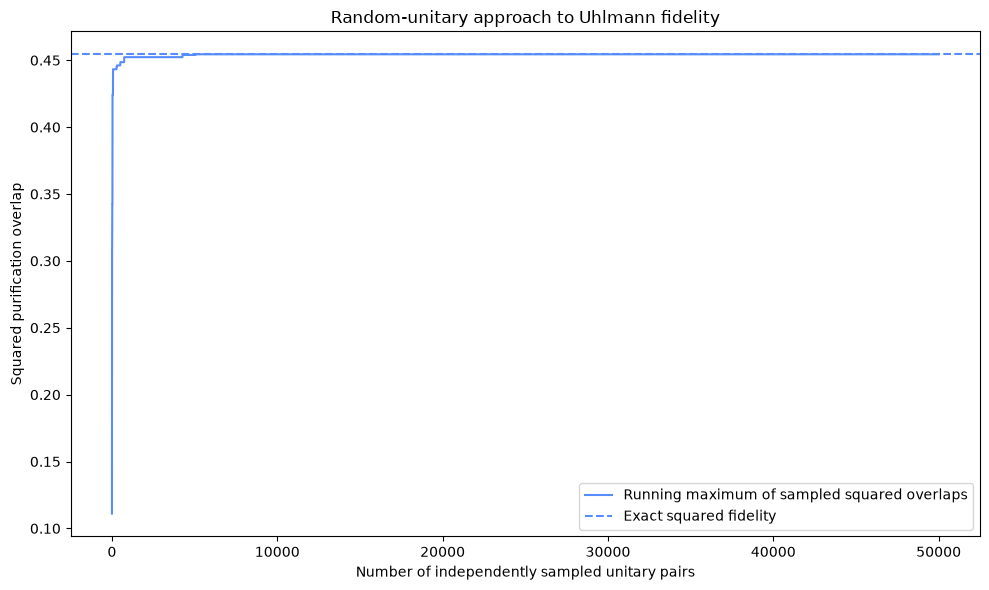

In [38]:
trial_numbers = np.arange(1, number_of_trials + 1)

plt.figure(figsize=(10, 6))
plt.plot(
    trial_numbers,
    running_maximum,
    label="Running maximum of sampled squared overlaps",
)
plt.axhline(
    exact_fidelity,
    linestyle="--",
    label="Exact squared fidelity",
)
plt.xlabel("Number of independently sampled unitary pairs")
plt.ylabel("Squared purification overlap")
plt.title("Random-unitary approach to Uhlmann fidelity")
plt.legend()
plt.tight_layout()
plt.show()

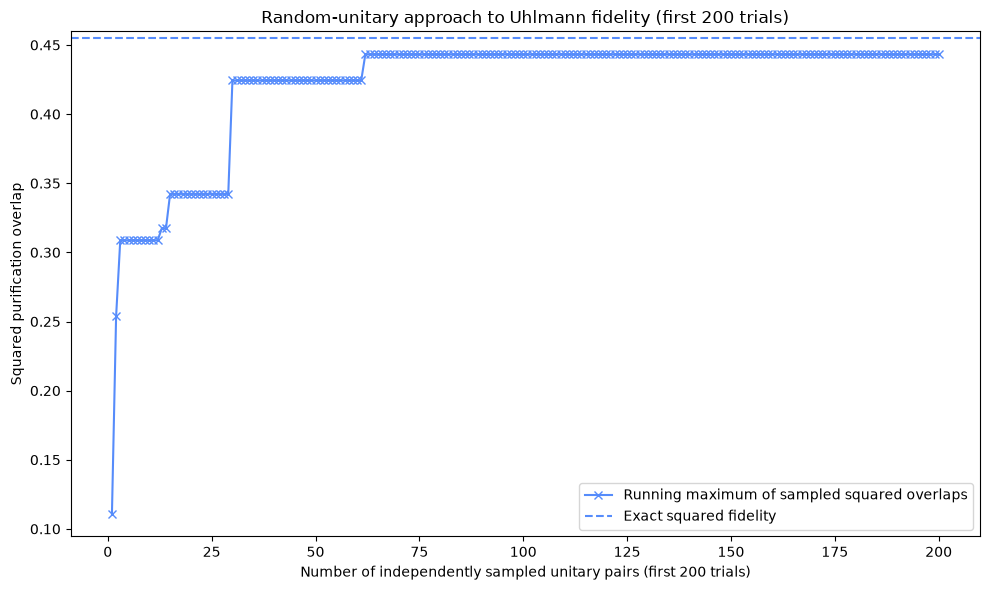

In [44]:
trial_numbers = np.arange(1, number_of_trials + 1)

plt.figure(figsize=(10, 6))
plt.plot(
    trial_numbers[:200],
    running_maximum[:200],
    linestyle="-",
    marker="x",
    label="Running maximum of sampled squared overlaps",
)
plt.axhline(
    exact_fidelity,
    linestyle="--",
    label="Exact squared fidelity",
)
plt.xlabel("Number of independently sampled unitary pairs (first 200 trials)")
plt.ylabel("Squared purification overlap")
plt.title("Random-unitary approach to Uhlmann fidelity (first 200 trials)")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Gap-to-optimum plot

To make late-stage convergence easier to see, plot

$$
F(\rho,\sigma)-M_N.
$$

A logarithmic vertical scale is useful because improvements become progressively smaller.

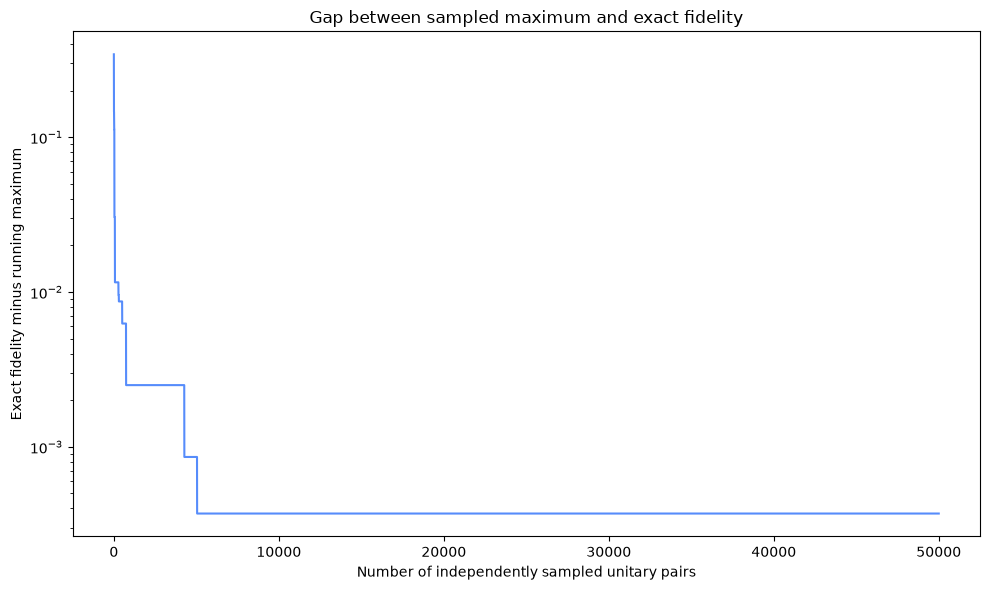

In [45]:
# Floating-point arithmetic can produce tiny negative values of order 10^{-15}.
# Clipping keeps the logarithmic plot well defined.
gap_to_optimum = np.maximum(
    exact_fidelity - running_maximum,
    np.finfo(float).tiny,
)

plt.figure(figsize=(10, 6))
plt.semilogy(trial_numbers, gap_to_optimum)
plt.xlabel("Number of independently sampled unitary pairs")
plt.ylabel("Exact fidelity minus running maximum")
plt.title("Gap between sampled maximum and exact fidelity")
plt.tight_layout()
plt.show()

## 13. Distribution of individual random overlaps

Most random unitary pairs are not close to optimal. The convergence occurs because the running maximum retains rare high-overlap samples.

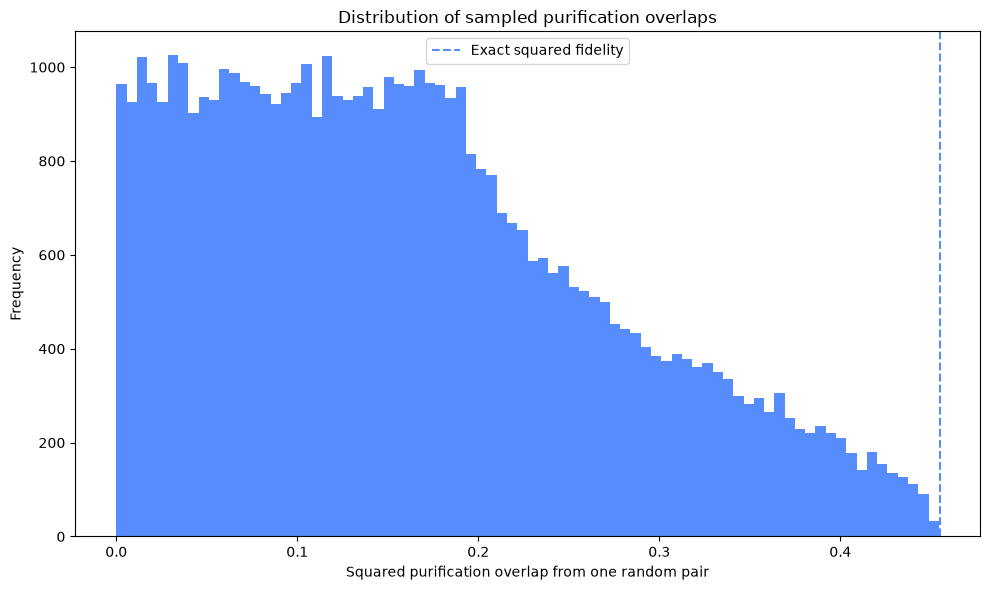

In [46]:
plt.figure(figsize=(10, 6))
plt.hist(sampled_overlaps, bins=80)
plt.axvline(
    exact_fidelity,
    linestyle="--",
    label="Exact squared fidelity",
)
plt.xlabel("Squared purification overlap from one random pair")
plt.ylabel("Frequency")
plt.title("Distribution of sampled purification overlaps")
plt.legend()
plt.tight_layout()
plt.show()

## 14. Interpretation

The numerical experiment demonstrates the variational content of Uhlmann’s theorem:

$$
F(\rho,\sigma)
=
\max_{U_\rho,U_\sigma}
\left|
\langle\Psi_\rho|
(U_\rho^\dagger U_\sigma\otimes I_A)
|\Psi_\sigma\rangle
\right|^2.
$$

The important observations are:

1. The purifications were constructed directly from the spectral decompositions of $\rho$ and $\sigma$.
2. Both reference systems were independently and symmetrically rotated.
3. Only the relative rotation $U_\rho^\dagger U_\sigma$ affects the overlap.
4. Every sampled overlap remains below the exact fidelity, apart from negligible floating-point roundoff.
5. The running maximum moves toward the exact value as more unitary pairs are sampled.

### Important limitation

Random search is a demonstration, not an efficient optimizer. In higher dimensions, the unitary group becomes much larger, and a naive Monte Carlo search may converge very slowly. The exact fidelity remains easy to compute directly from

$$
F(\rho,\sigma)
=
\left\|
\sqrt{\rho}\sqrt{\sigma}
\right\|_1^2.
$$

The value of the random-unitary experiment is conceptual: it makes the maximization over purification freedom visible.

## 15. Suggested experiments

Change the parameters near the beginning of the notebook and rerun all cells.

- Set $d=3$ to study qutrit states.
- Increase the number of trials to improve the sampled maximum.
- Change the random seed to generate a different pair of states.
- Compare convergence for nearly identical states and nearly orthogonal states.
- Replace one random density matrix with a pure-state projector and verify the pure–mixed formula

  $$
  F(\psi,\rho)
  =
  \langle\psi|\rho|\psi\rangle.
  $$

These variations provide useful numerical checks of the fidelity formulas developed in the lecture.